In [ ]:
!pip install lime fairlearn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.metrics import recall_score, make_scorer
from fairlearn.metrics import  selection_rate
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from sklearn.linear_model import LogisticRegression
from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference

In [ ]:


from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/drive/MyDrive/datasets/Predict_Student_Dropout_and_Academic_Success.csv"
# Make sure to set the correct delimiter
df = pd.read_csv(file_path, delimiter=";")

print(df.shape)
df.head()

(4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

⚠️ Important: Many columns look numeric but are actually categorical codes
(e.g., Marital status: 1=single, 2=married; Nationality: 1=Portuguese, 2=Angolan, etc.).
If we leave them as plain integers, the neural network will wrongly assume they have
a numeric order (e.g., 'Married(2)' > 'Single(1)'), which is meaningless.

✅ Solution for neural networks:
  1. First, explicitly mark these columns as categorical in pandas (so we keep track of them).
   2. Later, we will encode them for PyTorch:
      - One-hot encoding (for low-cardinality features, e.g., Marital status).
      - Embedding layers (for high-cardinality features, e.g., Course, Nationality).

This ensures the model treats categories as separate classes, not ordered numbers.


In [ ]:
# Columns that are categorical but stored as numbers
categorical_cols = [
    'Marital status', 'Application mode', 'Application order',
    'Course', 'Previous qualification', 'Nacionality',
    'Mother\'s qualification', 'Father\'s qualification',
    'Mother\'s occupation', 'Father\'s occupation'
]


# Convert to category dtype
for col in categorical_cols:
    df[col] = df[col].astype('category')

df[categorical_cols].head()


,Marital status,Application mode,Application order,Course,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation
0,1,17,5,171,1,1,19,12,5,9
1,1,15,1,9254,1,1,1,3,3,3
2,1,1,5,9070,1,1,37,37,9,9
3,1,17,2,9773,1,1,38,37,5,3
4,2,39,1,8014,1,1,37,38,9,9


In [ ]:
df.describe()

,Daytime/evening attendance\t,Previous qualification (grade),Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,0.890823,132.613314,126.978119,0.548373,0.011528,0.113698,0.880651,0.351718,0.248418,23.265145,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.311897,13.188332,14.482001,0.497711,0.106760,0.317480,0.324235,0.477560,0.432144,7.587816,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,0.000000,95.000000,95.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,125.000000,117.900000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,19.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,133.100000,126.100000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,20.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,140.000000,134.800000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,25.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,1.000000,190.000000,190.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,70.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


Dropping macroeconomic features (Unemployment rate, Inflation rate, GDP)
These variables reflect year-level economic conditions, not individual student characteristics.
They can leak admission year information and introduce bias, since the model could exploit differences between cohorts instead of focusing on student-level pre-enrollment features.
Therefore, we exclude them for a fairer and cleaner model.


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


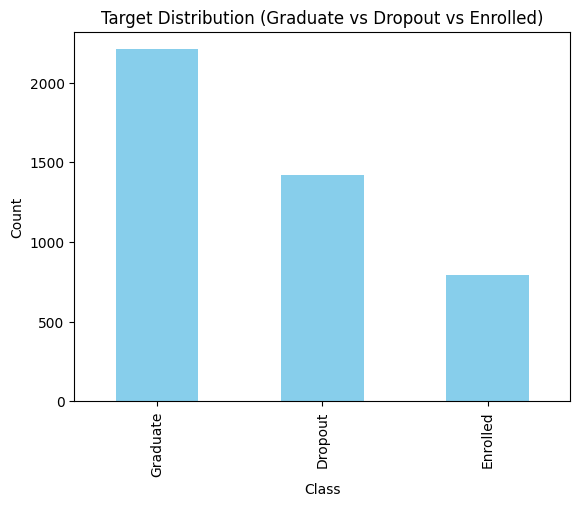

In [ ]:
# Check unique values and counts
print(df['Target'].value_counts())

# Plot distribution
df['Target'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Target Distribution (Graduate vs Dropout vs Enrolled)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
df = df.drop(columns=["Unemployment rate", "Inflation rate", "GDP"])

⚠️ Removing "leaky" features:
These columns contain information that would only be known *after* a student has already started or even finished their studies
(e.g., grades, credits, enrollment evaluations).
Keeping them would give the model unfair "hints" about the target (Graduate/Dropout),
leading to overly optimistic results (data leakage). For a fair prediction task, we only keep features available at the time of enrollment.

In [ ]:
leaky_features = [
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
]

df = df.drop(columns=leaky_features)

In [ ]:
# Map text labels to numeric codes, overwrite Target column
target_mapping = {
    "Graduate": 0,
    "Dropout": 1,
    "Enrolled": 2
}

df['Target'] = df['Target'].map(target_mapping).astype(int)

# Confirm changes
print(df['Target'].value_counts())
print(df.dtypes['Target'])


Target
0    2209
1    1421
2     794
Name: count, dtype: int64
int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   Marital status                  4424 non-null   category
 1   Application mode                4424 non-null   category
 2   Application order               4424 non-null   category
 3   Course                          4424 non-null   category
 4   Daytime/evening attendance	     4424 non-null   int64   
 5   Previous qualification          4424 non-null   category
 6   Previous qualification (grade)  4424 non-null   float64 
 7   Nacionality                     4424 non-null   category
 8   Mother's qualification          4424 non-null   category
 9   Father's qualification          4424 non-null   category
 10  Mother's occupation             4424 non-null   category
 11  Father's occupation             4424 non-null   category
 12  Admission grade     

**EDA**

Distribution of Numerical Features

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


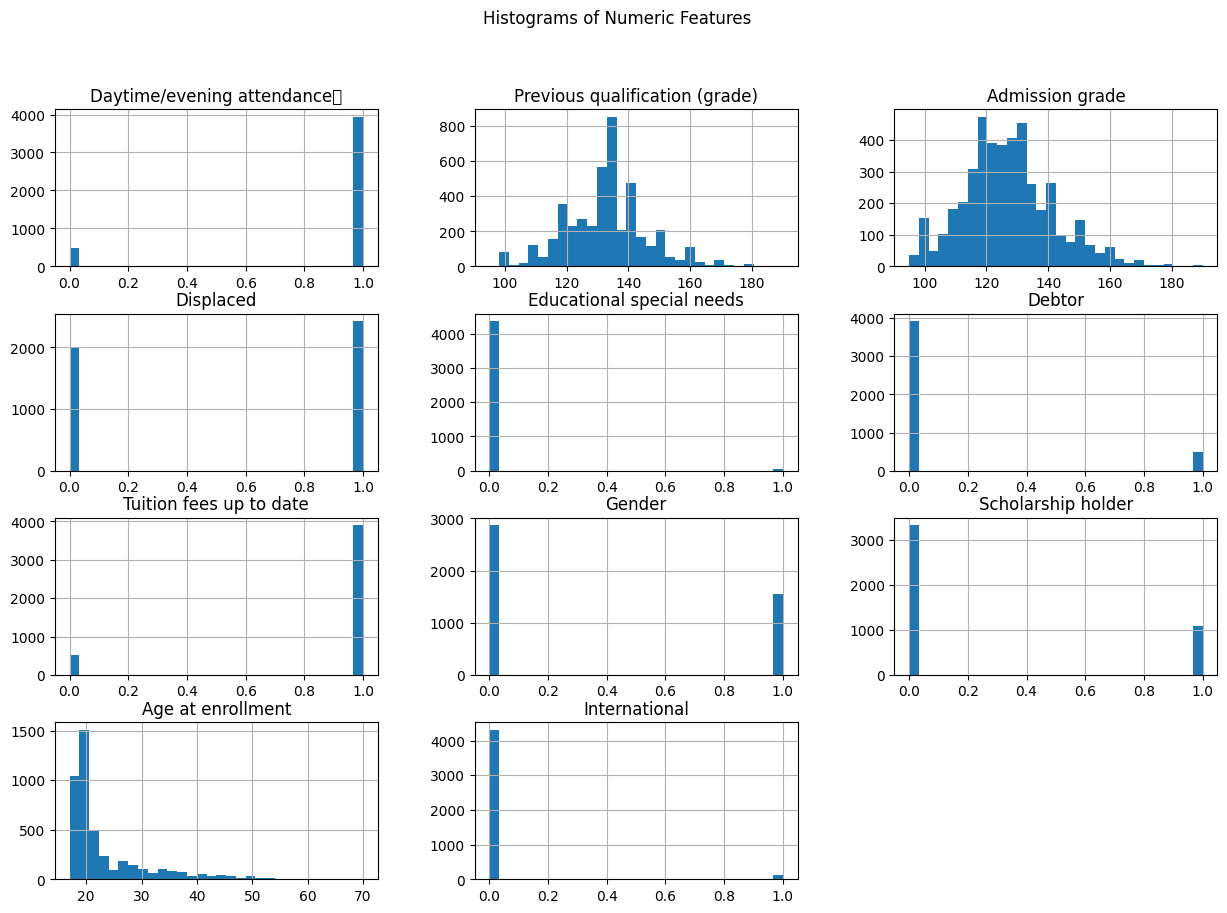

In [ ]:
# This helps us see skewness, ranges, and potential outliers.
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Target')

df[numeric_cols].hist(bins=30, figsize=(15,10))
plt.suptitle("Histograms of Numeric Features")
plt.show()


Correlation Between Numerical Features

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


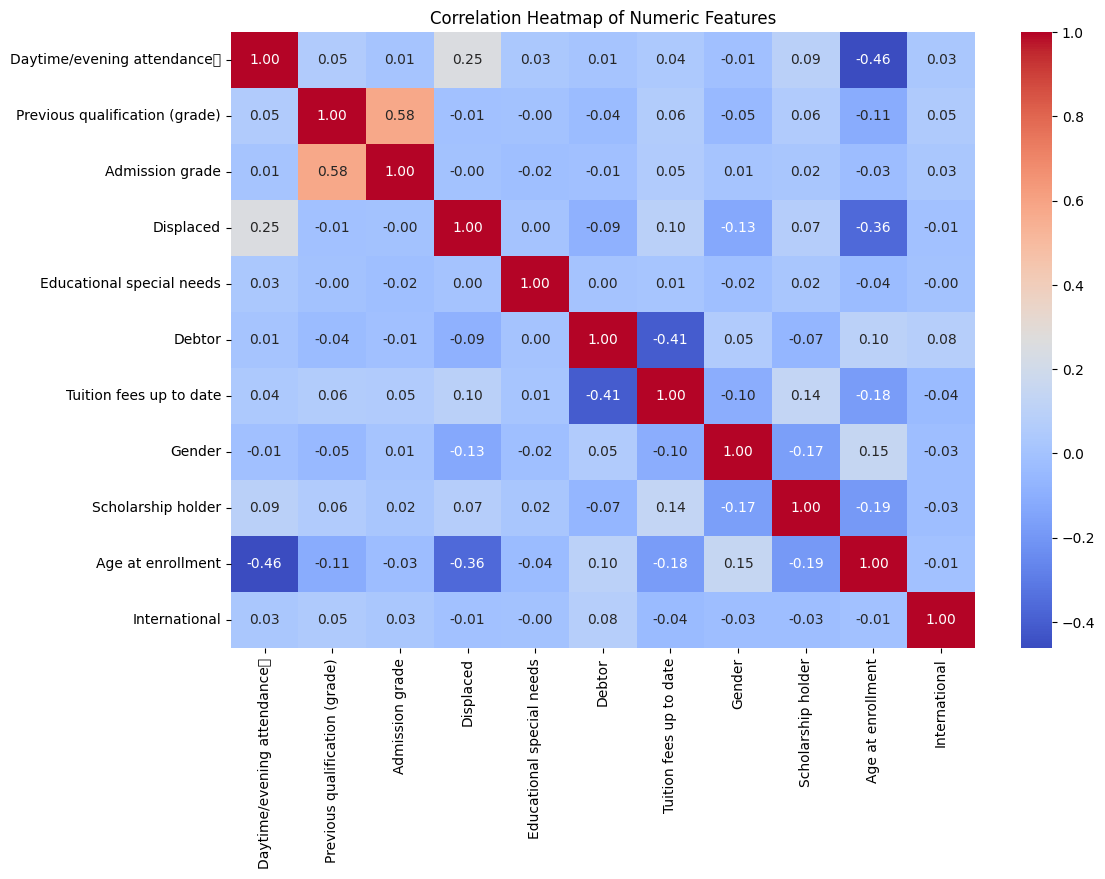

In [ ]:
# This helps detect multicollinearity (features that are strongly correlated).
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


**Categorical Feature Cardinality**

Number of unique categories per categorical feature
This helps us spot high-cardinality columns (many unique values), which may need special handling.

In [ ]:
cat_cols = df.select_dtypes(include=['category']).columns

for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")

Marital status: 6 unique values
Application mode: 18 unique values
Application order: 8 unique values
Course: 17 unique values
Previous qualification: 17 unique values
Nacionality: 21 unique values
Mother's qualification: 29 unique values
Father's qualification: 34 unique values
Mother's occupation: 32 unique values
Father's occupation: 46 unique values


**Distribution of Categorical Features**

We want to see if some categories dominate (e.g., one nationality is 90% of data).

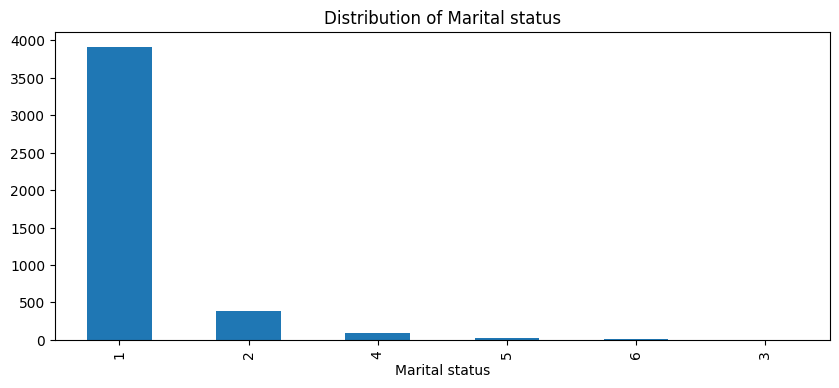

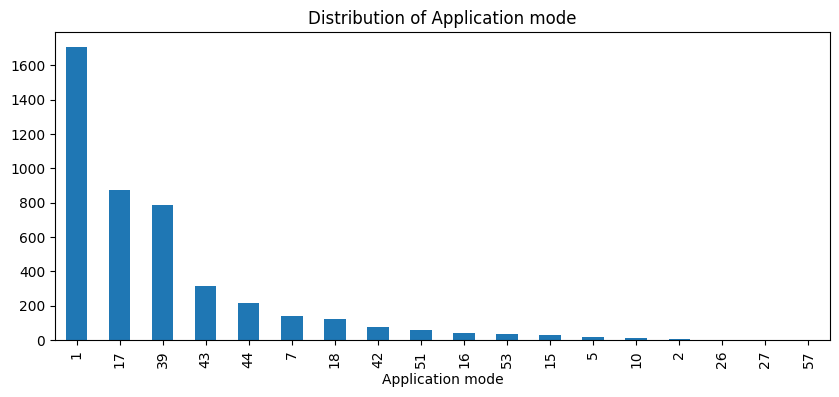

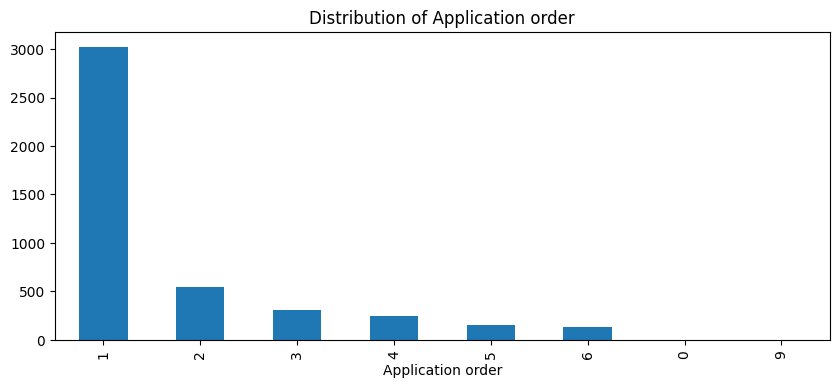

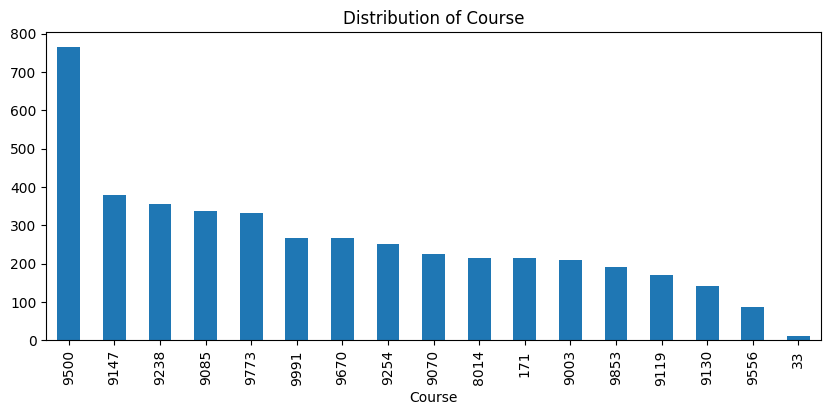

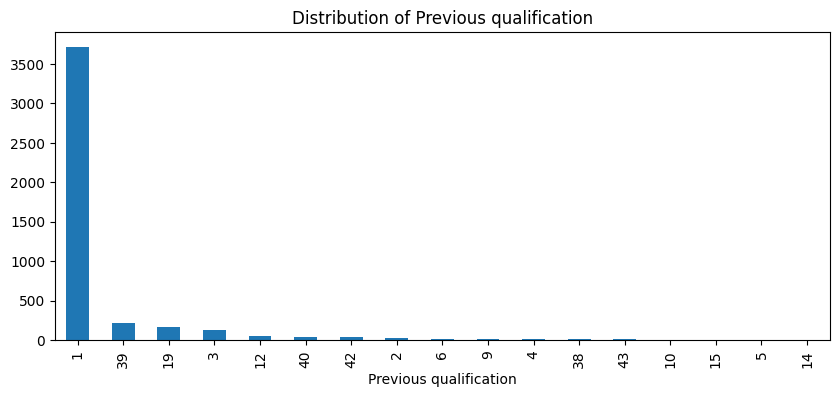

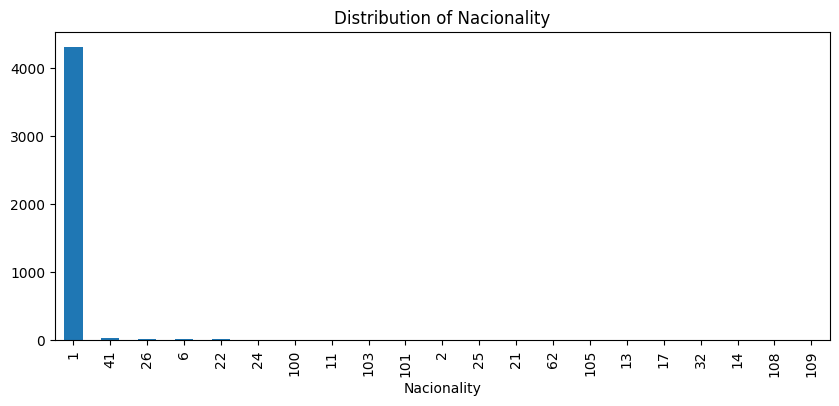

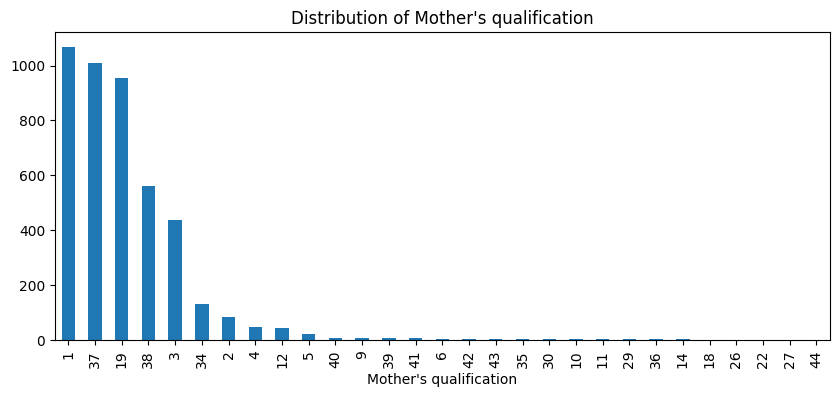

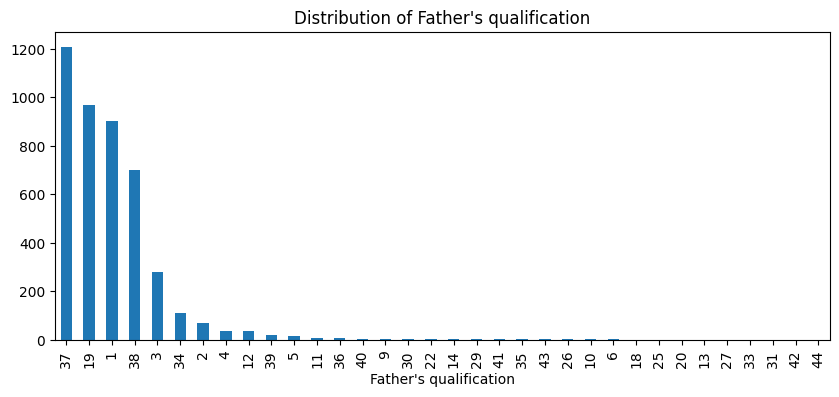

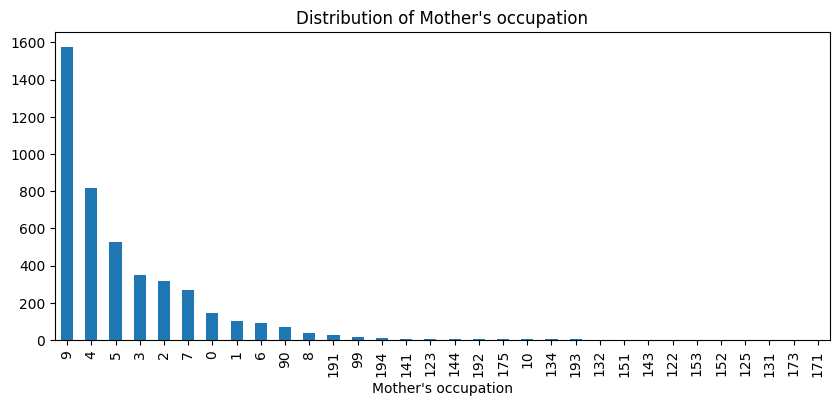

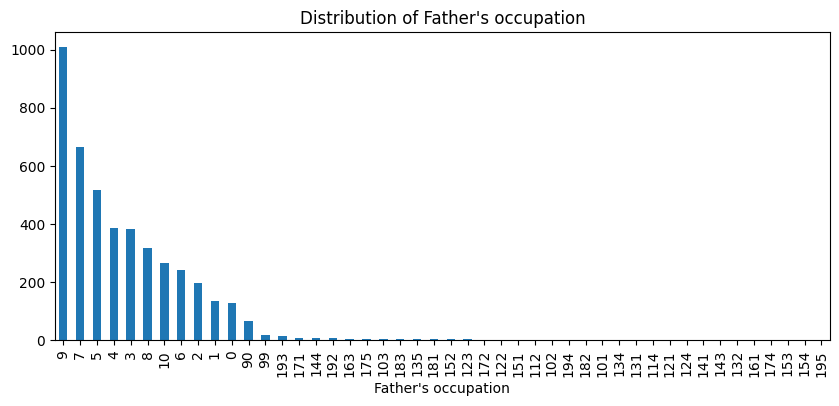

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(10,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Distribution of {col}")
    plt.show()

Target vs Categorical Features

Target distribution across categories helps us see patterns like: Do certain groups (e.g., Gender, Nationality) have more dropouts?
for col in cat_cols:

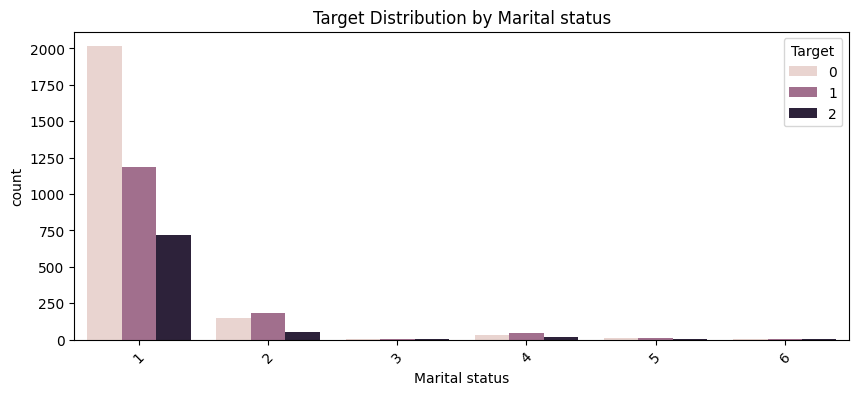

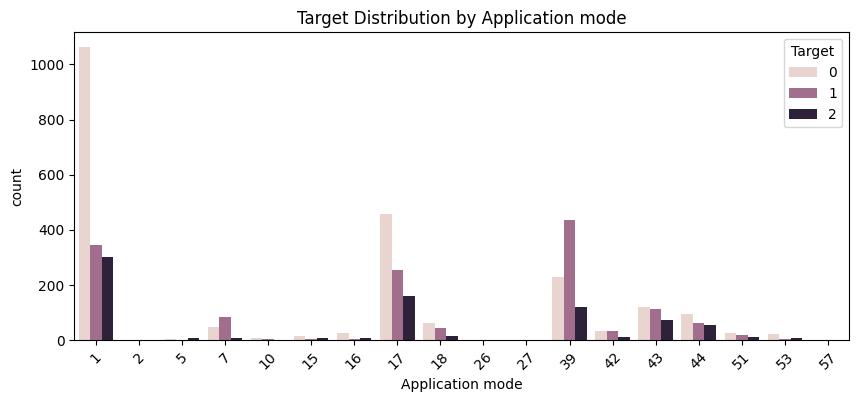

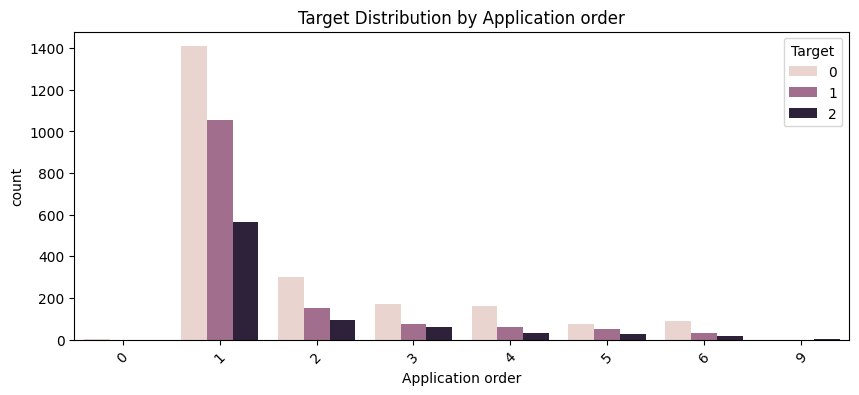

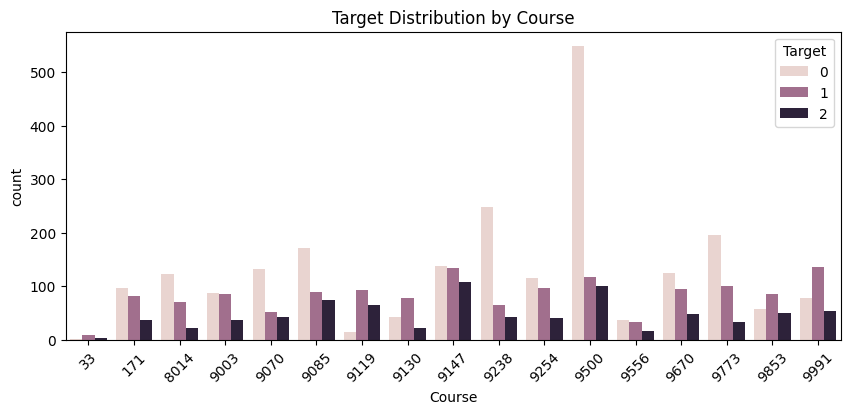

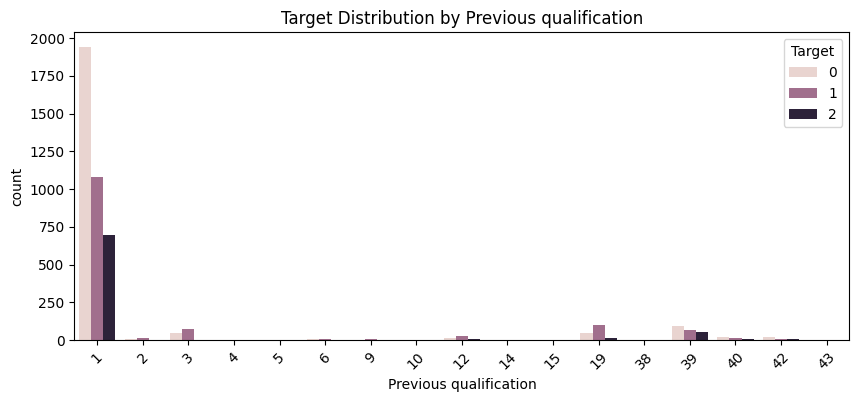

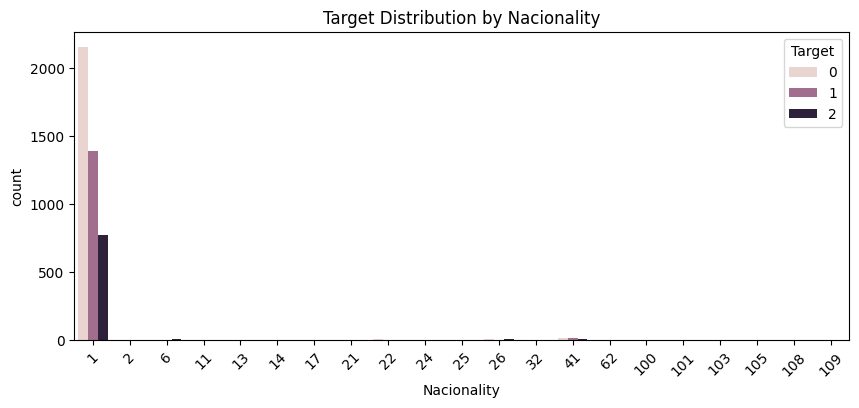

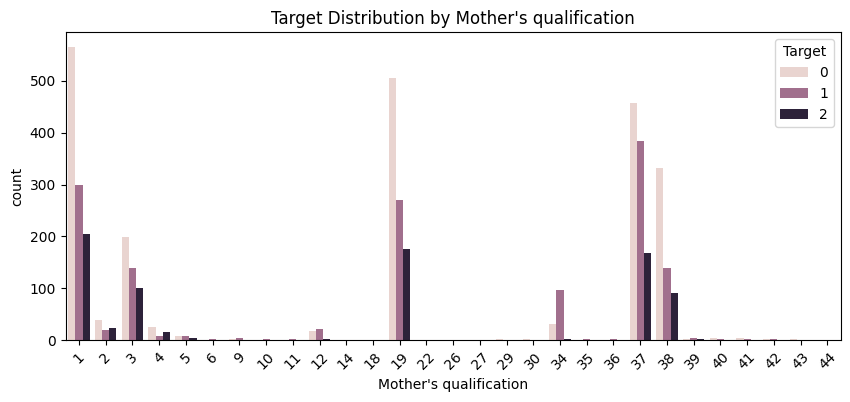

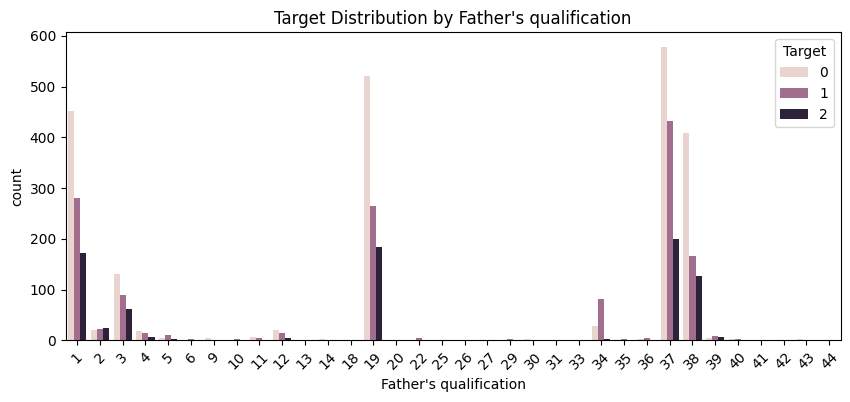

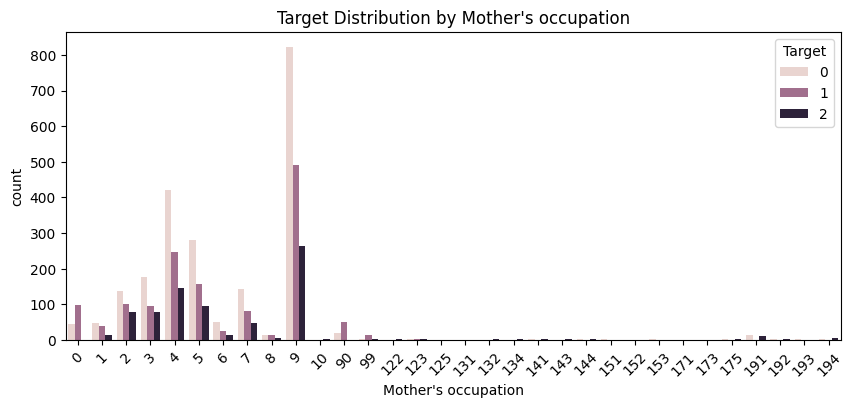

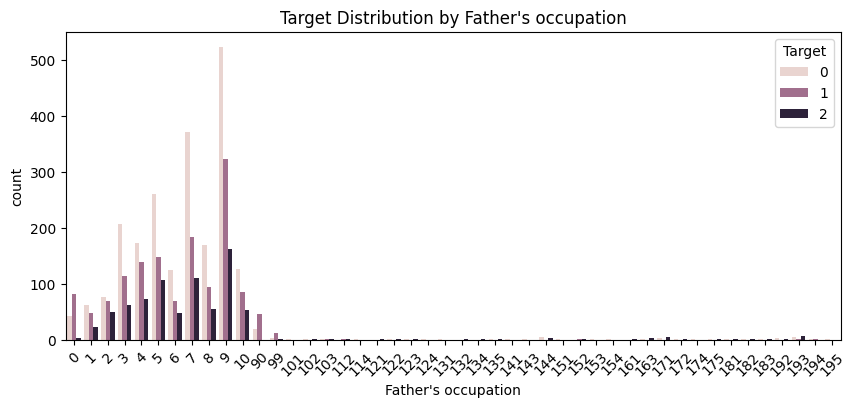

In [ ]:
cat_cols = df.select_dtypes(include=['category']).columns
for col in cat_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(data=df, x=col, hue="Target")
    plt.title(f"Target Distribution by {col}")
    plt.xticks(rotation=45)
    plt.show()



*   Marital status '2' (married) shows higher dropout rates.
*   Courses 9119, 9140, 9991 have more students dropping out.

*   Application mode 39 (students over 23 years old) shows higher dropout rates.
*   Mother's qualification and father's qualification '37' (Basic education 1st cycle) has a high dropout rate, close to graduates.

*   Mother's occupation (unskilled workers) and father's occupation reflect high counts in both graduates and dropouts.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


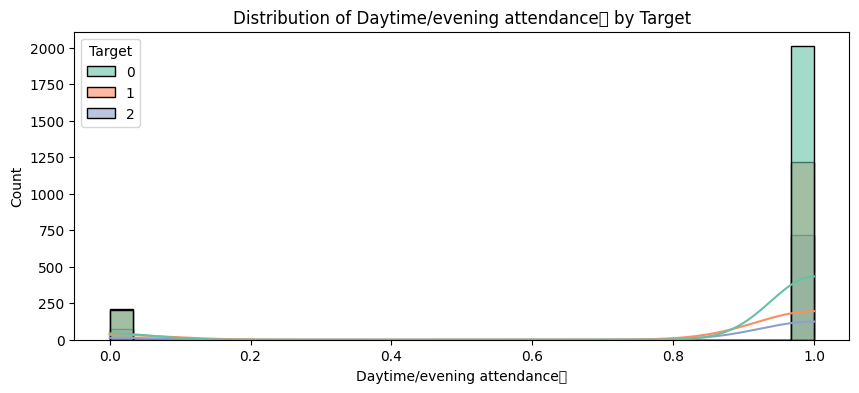

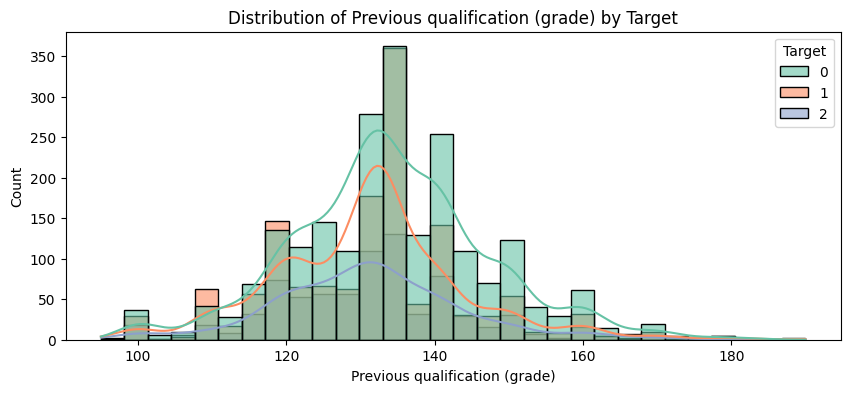

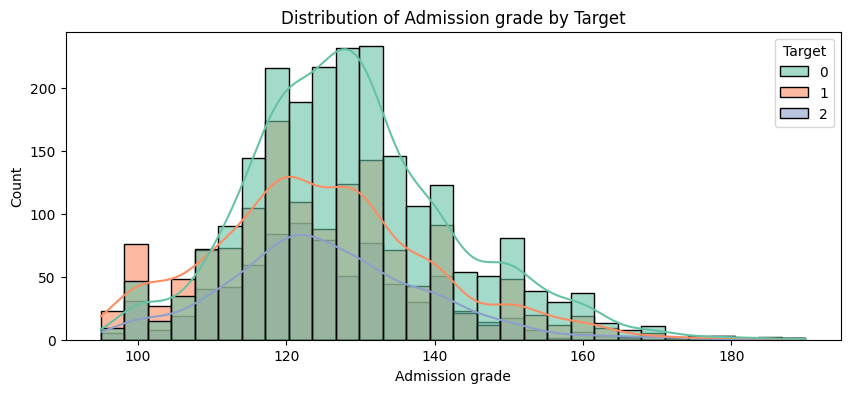

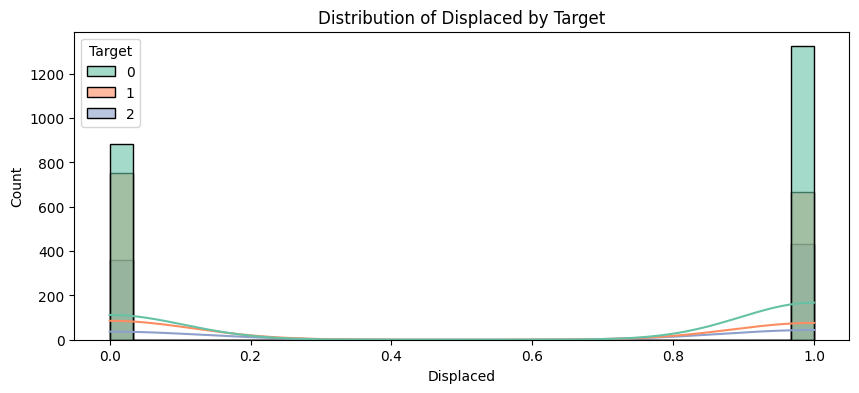

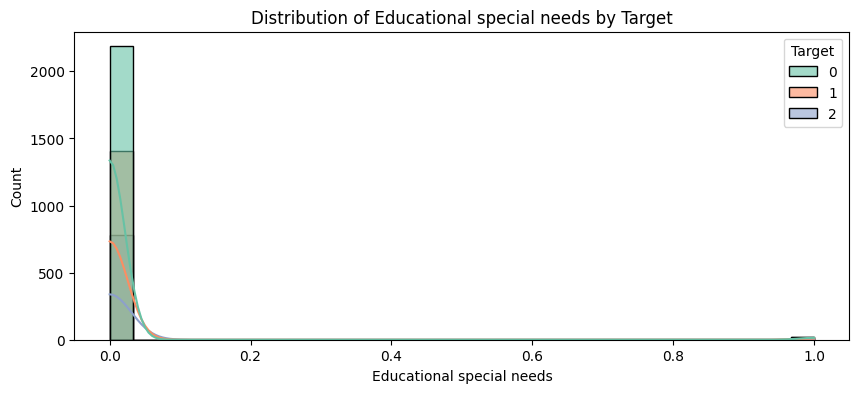

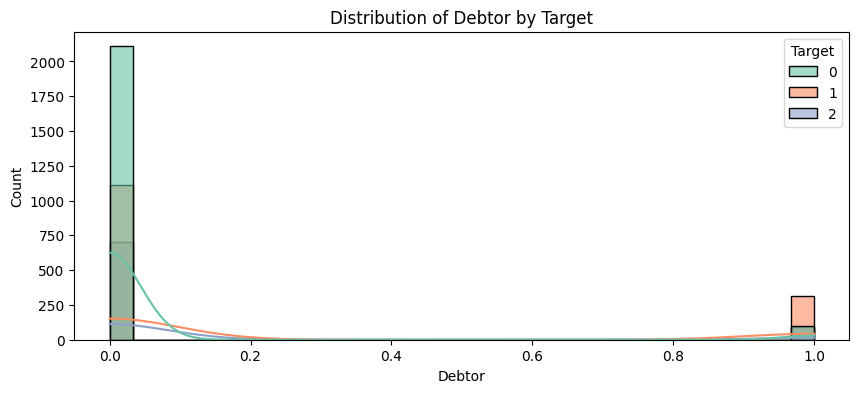

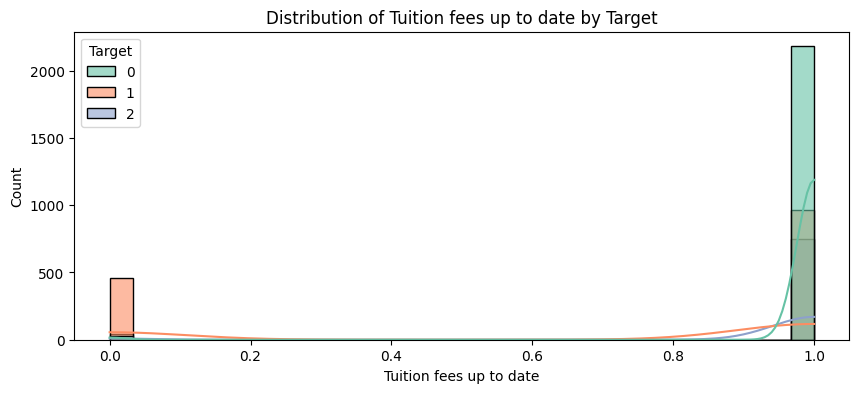

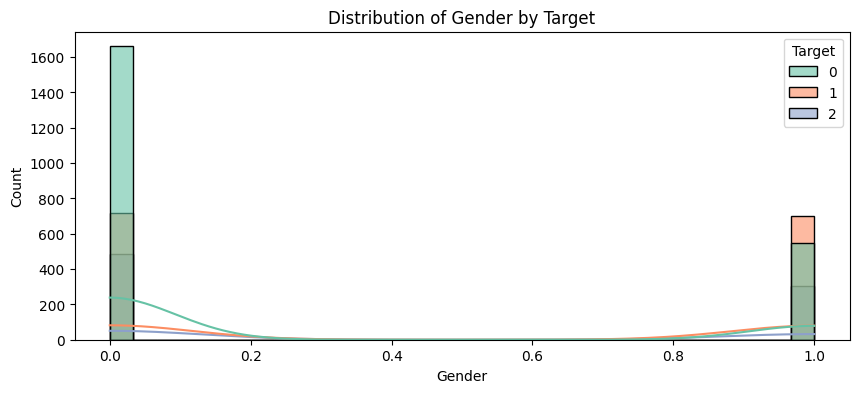

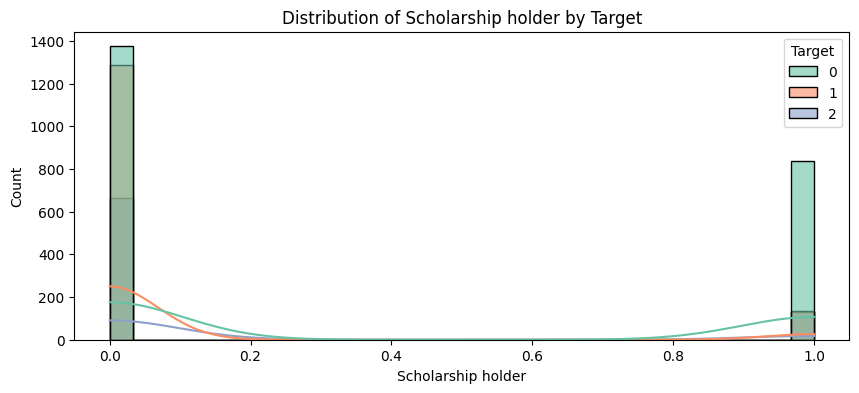

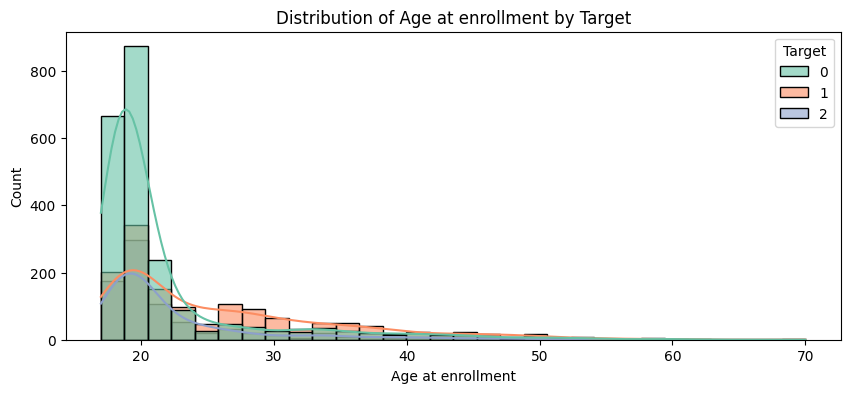

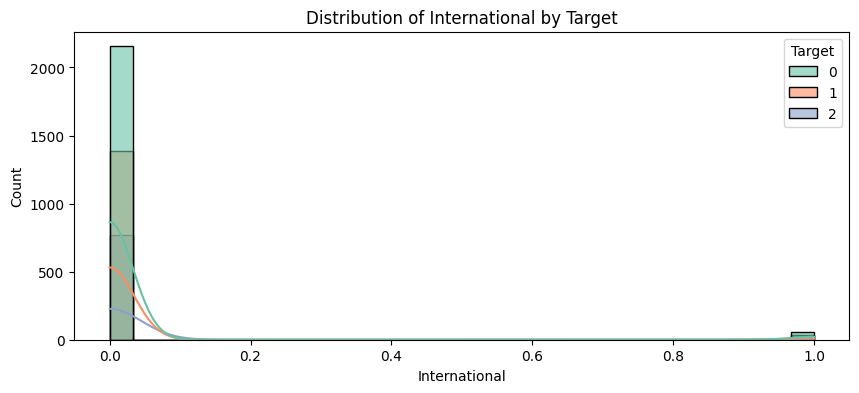

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = [col for col in num_cols if col != 'Target']  # exclude target

for col in num_cols:
    plt.figure(figsize=(10,4))
    # Histogram + KDE by target
    sns.histplot(data=df, x=col, hue="Target", kde=True, bins=30, palette="Set2", alpha=0.6)
    plt.title(f"Distribution of {col} by Target")
    plt.show()


**Observations**

Gender: Male students have a higher dropout rate compared to female students.

Financial status: Students who are  debtors or have unpaid tuition fees show higher dropout rates.

Age: Students aged 25+ are more likely to drop out than younger students.

**PREPROCESSING**

**Note on Sensitive Attributes and Fairness**

In fairness-aware machine learning, features such as Gender, Age, Nationality, International status, Displacement status, and Educational special needs are considered sensitive attributes. Including these features in the training data may cause the model to learn biased associations (e.g., assuming that older students or males are more likely to drop out), which can result in unfair or discriminatory predictions.

The recommended practice is to:

Remove sensitive attributes from the training dataset so the model does not directly rely on them.

Store them separately for fairness auditing after training. This allows us to evaluate whether the model’s predictions are biased across sensitive groups (e.g., does the model predict higher dropout risk for women compared to men, even when other factors are the same?).

In [ ]:
sensitive_features = ["Gender", "Age at enrollment", "Nacionality",
                      "International", "Displaced", "Educational special needs"]

# Save sensitive attributes for fairness auditing
sensitive_attributes = df[sensitive_features]

# Define training features (drop Target + sensitive attributes)
X = df.drop(columns=["Target"] + sensitive_features)

# Define target variable
y = df["Target"]

In [ ]:
# Convert categoricals into dummy/one-hot columns
X_encoded = pd.get_dummies(X, drop_first=True)  # drop_first avoids dummy variable trap

# Train / Validation / Test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

In [ ]:
# Define model

xgb_model = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=len(y.unique()),  # auto-detect number of classes
    eval_metric="mlogloss",
    random_state=42,
    use_label_encoder=False
)

# Train with class balancing

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

xgb_model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=True
)


# Predict & Evaluate

y_pred = xgb_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

[0]	validation_0-mlogloss:1.02791


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [20:02:14] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[1]	validation_0-mlogloss:0.98926
[2]	validation_0-mlogloss:0.96112
[3]	validation_0-mlogloss:0.94401
[4]	validation_0-mlogloss:0.93083
[5]	validation_0-mlogloss:0.92182
[6]	validation_0-mlogloss:0.91212
[7]	validation_0-mlogloss:0.90463
[8]	validation_0-mlogloss:0.90090
[9]	validation_0-mlogloss:0.89735
[10]	validation_0-mlogloss:0.89090
[11]	validation_0-mlogloss:0.89044
[12]	validation_0-mlogloss:0.88640
[13]	validation_0-mlogloss:0.88348
[14]	validation_0-mlogloss:0.88449
[15]	validation_0-mlogloss:0.88349
[16]	validation_0-mlogloss:0.88618
[17]	validation_0-mlogloss:0.88400
[18]	validation_0-mlogloss:0.88238
[19]	validation_0-mlogloss:0.87919
[20]	validation_0-mlogloss:0.88196
[21]	validation_0-mlogloss:0.88175
[22]	validation_0-mlogloss:0.88217
[23]	validation_0-mlogloss:0.88081
[24]	validation_0-mlogloss:0.88067
[25]	validation_0-mlogloss:0.88039
[26]	validation_0-mlogloss:0.88061
[27]	validation_0-mlogloss:0.88110
[28]	validation_0-mlogloss:0.88303
[29]	validation_0-mlogloss:0.

We connect SHAP to the trained XGBoost model and generate SHAP values for the test set. These values show how each feature contributes to predictions.

In [ ]:
# Create SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Explain predictions on the test set
shap_values = explainer.shap_values(X_test)


We visualize overall feature importance. This tells us which features are most influential across the whole dataset, helping us see general patterns.

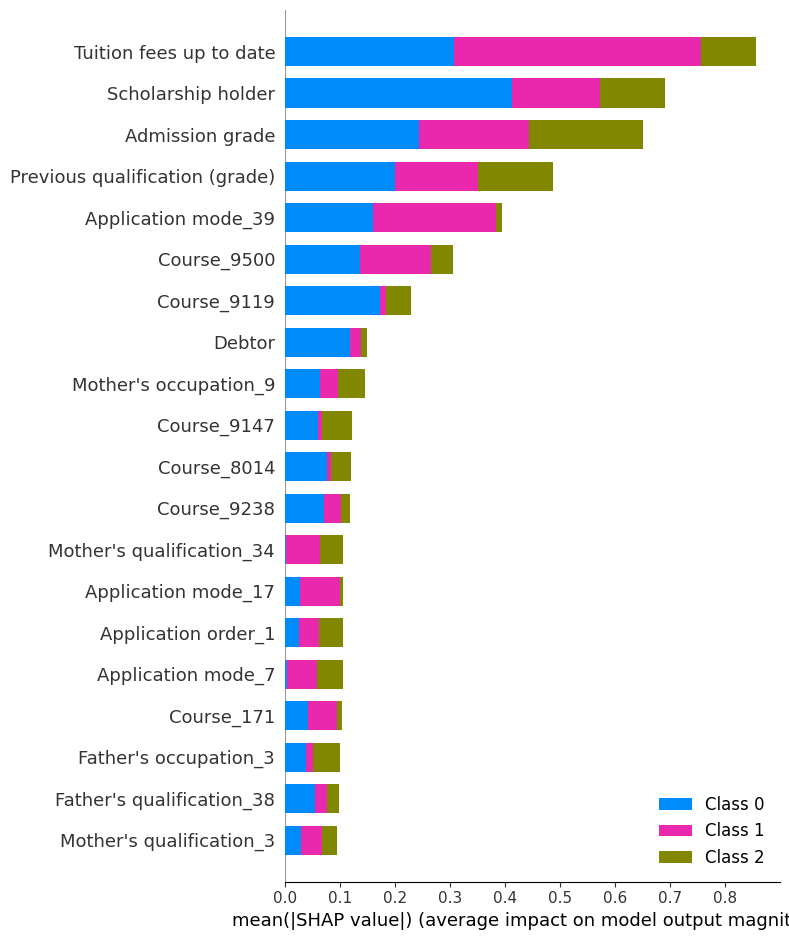

In [ ]:
  shap.summary_plot(shap_values, X_test, plot_type="bar")

Result: “SHAP shows that tuition fees up to date, scholarship quota, admission grade, previous qualification, and course choice are the most influential factors in predicting student dropout/continuation.”

👉 Interpretation (Responsible AI lens):

These results suggest that financial and academic factors are the main drivers of the model’s decisions.

This is not surprising — students struggling financially or with weaker academic history are more at risk of dropout.

Importantly, these features are not inherently sensitive attributes, but they may reflect structural inequalities (e.g., lower-income backgrounds).

Before finalizing recommendations, we will extend this analysis with LIME for local explanations and a fairness audit to ensure that these risk factors are not disproportionately impacting vulnerable subgroups

While SHAP gave us global explanations (what features matter overall), LIME lets us zoom in on individual predictions (why the model predicted dropout for this specific student).

In [ ]:
# Initialize LIME explainer
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['Graduate', 'Dropout', 'Enrolled'],
    mode='classification'
)

# Pick one student from test set (example: index 15)
student_idx = 15
exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[student_idx],
    predict_fn=xgb_model.predict_proba
)

# Show explanation
exp.show_in_notebook(show_table=True)
# Or save to HTML if working outside notebook
exp.save_to_file('lime_explanation.html')

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

For this student, the model predicted a 45% chance of dropout, mainly influenced by their application mode and parental occupation/qualification categories. This suggests the model has learned patterns where certain application modes or socioeconomic factors correlate with dropout risk.


While this improves interpretability, we need to pause: socioeconomic features like parental occupation or prior qualifications may reflect structural disadvantages. Even if we excluded sensitive attributes like gender or nationality, this shows proxy bias might remain, the model could indirectly penalize students from specific backgrounds. Hence, the next step is to conduct a fairness audit, so we can check whether these patterns lead to unfair outcomes

In [ ]:
sensitive_attributes = df[sensitive_features]

# Step 1: Copy sensitive attributes for test set only
sens_test = sensitive_attributes.loc[X_test.index].copy()

# Group Age into bins
sens_test["AgeGroup"] = pd.cut(sens_test["Age at enrollment"],
                               bins=[17, 22, 30, 100],
                               labels=["18-22", "23-30", "31+"])

# Simplify Nationality → Domestic vs International
sens_test["IsInternational"] = np.where(sens_test["Nacionality"] == 1,
                                        "Domestic", "International")

audit_features = ["Gender", "AgeGroup", "IsInternational", "Displaced", "Educational special needs"]

# Step 2: Run fairness audit
results = []

for feature in audit_features:
    group_values = sens_test[feature]

    mf = MetricFrame(metrics={
                        "Accuracy": accuracy_score,
                        "Selection Rate": lambda y_true, y_pred: selection_rate(y_true, y_pred, pos_label=1),
                        "Recall": lambda y_true, y_pred: recall_score(y_true, y_pred, average="macro")
                    },
                    y_true=y_test,
                    y_pred=y_pred,
                    sensitive_features=group_values)

    # Collect results by group
    df_group = mf.by_group.reset_index()
    df_group = df_group.rename(columns={feature: "Group"})
    df_group["Sensitive Feature"] = feature
    results.append(df_group)

# Combine into one table
fairness_df = pd.concat(results, ignore_index=True)

# --- Step 3: Add disparity (max - min) for each feature ---
gap_summary  = fairness_df.groupby("Sensitive Feature")[["Accuracy","Selection Rate","Recall"]].agg(['min','max'])
gap_summary["Accuracy Gap"] = gap_summary["Accuracy"]["max"] - gap_summary["Accuracy"]["min"]
gap_summary["Selection Gap"] = gap_summary["Selection Rate"]["max"] - gap_summary["Selection Rate"]["min"]
gap_summary["Recall Gap"] = gap_summary["Recall"]["max"] - gap_summary["Recall"]["min"]

# --- Step 4: Display ---
print("🔹 Fairness Audit Dashboard\n")
print(fairness_df[["Sensitive Feature","Group","Accuracy","Selection Rate","Recall"]])
print("\n🔹 Gap Summary (max-min disparity)\n")
print(gap_summary[["Accuracy Gap","Selection Gap","Recall Gap"]])

🔹 Fairness Audit Dashboard

            Sensitive Feature          Group  Accuracy  Selection Rate  \
0                      Gender              0  0.625304        0.250608   
1                      Gender              1  0.549407        0.375494   
2                    AgeGroup          18-22  0.609071        0.185745   
3                    AgeGroup          23-30  0.572917        0.583333   
4                    AgeGroup            31+  0.561905        0.533333   
5             IsInternational       Domestic  0.594761        0.295840   
6             IsInternational  International  0.666667        0.400000   
7                   Displaced              0  0.569930        0.384615   
8                   Displaced              1  0.616402        0.232804   
9   Educational special needs              0  0.596947        0.299237   
10  Educational special needs              1  0.555556        0.222222   

      Recall  
0   0.560003  
1   0.526400  
2   0.536603  
3   0.492715  
4   0.45

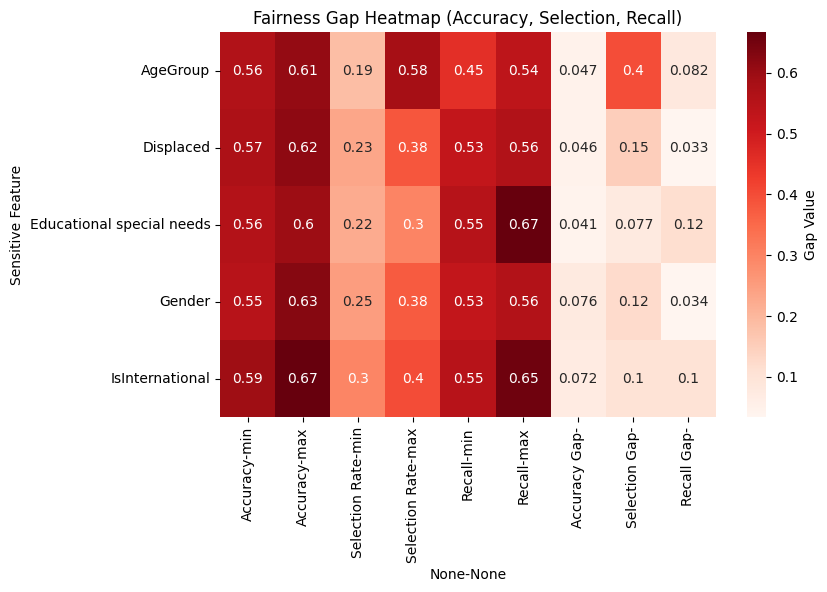

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(gap_summary, annot=True, cmap="Reds", cbar_kws={'label': 'Gap Value'})
plt.title("Fairness Gap Heatmap (Accuracy, Selection, Recall)")
plt.show()

The fairness audit reveals disparities across sensitive groups in dropout prediction. Age groups show the largest disparity, with older students much more likely to be flagged as dropouts than younger ones. Gender shows bias against females (lower accuracy and higher dropout prediction). International students have higher accuracy and recall, but are predicted as dropouts more frequently than domestic students. Displaced and special needs students display smaller but still notable differences. Overall, the results highlight the need for caution: while the model is functional, it risks unfairly treating certain student subgroups if deployed without bias mitigation.

In [ ]:

# Convert target to binary: dropout (1) vs non-dropout (0)
binary_y_test = (y_test == 1).astype(int)
binary_y_pred = (y_pred == 1).astype(int)

# Store results
results = []

for feat in sensitive_features:   # loop over Gender, Age, etc.
    group_values = sens_test[feat]

    # MetricFrame for per-group metrics
    mf = MetricFrame(metrics={
            "Accuracy": accuracy_score,
            "Selection Rate": selection_rate
        },
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=group_values
    )

    # Fairness metrics
    dp_diff = demographic_parity_difference(
        binary_y_test, binary_y_pred, sensitive_features=group_values
    )
    eo_diff = equalized_odds_difference(
        binary_y_test, binary_y_pred, sensitive_features=group_values
    )

    # Save
    results.append({
        "Sensitive Feature": feat,
        "Accuracy by Group": mf.by_group.to_dict(),
        "Selection Rate by Group": mf.by_group["Selection Rate"].to_dict(),
        "DP Difference": dp_diff,
        "EO Difference": eo_diff
    })

# Put everything in a dataframe for readability
fairness_results = pd.DataFrame(results)

print("\n🔹 Fairness Audit Results")
print(fairness_results[["Sensitive Feature", "DP Difference", "EO Difference"]])




🔹 Fairness Audit Results
           Sensitive Feature  DP Difference  EO Difference
0                     Gender       0.124886       0.034483
1          Age at enrollment       1.000000       1.000000
2                Nacionality       1.000000       1.000000
3              International       0.104160       0.411483
4                  Displaced       0.151811       0.088904
5  Educational special needs       0.077014       0.352871
